# Notebook 05 — Model Training
## NBA Contract Value Index (CVI)

This notebook trains the binary logistic regression classifier
that powers the CVI model's contract worthiness predictions.

Up to this point we used rule-based thresholds to assign verdicts.
This notebook adds a learned model — one that finds the optimal
decision boundary from historical labeled data.

---

### What This Notebook Does

| Step | Action | Output |
|------|--------|--------|
| 1 | Pull team standings (win%) | `standings` DataFrame |
| 2 | Create binary labels from raw stats | `LABEL` column (1=good, 0=bad) |
| 3 | Build feature matrix | X (13 features) + y (labels) |
| 4 | Train logistic regression | Trained pipeline |
| 5 | Evaluate with cross-validation + ROC curve | ROC-AUC score |
| 6 | Score current 2025-26 players | MODEL_PROB (0-100) |
| 7 | Compare model vs rule-based verdicts | Agreement rate + disagreements |
| 8 | Save model + scored dataset | .pkl + master_scored.csv |

---

### The Labeling Problem — V2 Approach

The hardest part of this notebook is creating labels.
We need to answer: "Was this a good contract in hindsight?"

**V1 labeling (discarded):** Used CVI feature scores as labeling criteria.
This created data leakage — features predicted labels derived from
those same features. ROC-AUC was artificially inflated to 0.995.

**V2 labeling (current):** Uses raw observable stats only.
Four criteria — all independent of CVI feature scores:

| Criterion | Raw Signal | Threshold |
|-----------|-----------|-----------|
| Team performance | Raw win% | ≥ 0.500 |
| Player production | Raw BPM by tier | franchise≥4.0, max≥2.0, star≥0.5 |
| Availability | Raw games played | ≥ 53 of 82 (65%) |
| Salary burden | Raw salary share | ≤ 30% of team payroll |

3 of 4 conditions = good contract (label = 1)
Fewer than 3 = bad contract (label = 0)
Exactly 2 = edge case, excluded from training (-1)

---

### Model Performance

| Metric | Value |
|--------|-------|
| ROC-AUC (5-fold CV) | 0.981 ± 0.004 |
| Accuracy (5-fold CV) | 0.936 ± 0.013 |
| Test ROC-AUC (20% holdout) | 0.980 |
| Training samples | 1,068 |
| Features | 13 |

---

### Key Findings

**Top features by coefficient (what the model learned):**
1. Availability Score (3.056) — strongest predictor of good contracts
2. Win Impact Score (2.499) — second strongest
3. Accolades Score (1.438) — pedigree matters
4. Cap Efficiency Score (0.986) — production per dollar
5. Overpaid Max Flag (-0.952) — max players underperforming = bad signal

**Model vs rule-based agreement: 51.3%**
The two approaches disagree half the time — not a failure.
They answer different questions:
- Rule-based CVI: "Is this contract good for the team's roster construction?"
- Model probability: "Does this contract pattern match historical good contracts?"

Key disagreements surface the most interesting cases:
- Model says good, rules say bad: Mitchell, Butler, Curry, Embiid
  → Good players whose team cap situation hurts their rule-based score
- Model says bad, rules say good: Hachimura, role players
  → Players whose stats don't match typical good contract patterns

---

### Why Logistic Regression

Logistic regression is the right starting model because:
1. Explainable — coefficients show exactly why a contract scored the way it did
2. Probabilistic — outputs a 0-100 probability, not just good/bad
3. Defensible — a GM can understand and challenge the reasoning
4. Fast — trains in milliseconds, easy to retrain each season

---

### Data Flow

data/processed/master_with_playoffs.csv   ← input
↓

05_model_training.ipynb
↓

models/cvi_logistic_model.pkl             ← trained model

data/processed/master_scored.csv          ← final output with model probabilities

---

### Output Columns Added

| Column | Description |
|--------|-------------|
| `LABEL` | Binary label — 1=good, 0=bad, NaN=current season |
| `LABEL_SOURCE` | How labeled — auto_v2 |
| `CONDITIONS_MET` | How many of 4 criteria were met |
| `TEAM_WINPCT` | Team win% for that season (labeling input) |
| `MODEL_PROB` | Logistic regression probability (0-100) |
| `MODEL_VERDICT` | good (≥65) / borderline (45-64) / bad (<45) |

---

### Notes for V2
- Add XGBoost comparison model with SHAP feature importance plots
- Expand training data to 2015-16 onward for larger sample
- Add more labeling seasons as each season completes
- Investigate why ROC-AUC remains high (0.981) despite v2 label fix
  — may still have some feature/label correlation worth addressing
- Consider separate models per salary tier
- Add manual label overrides for obvious cases (Ben Simmons = 0 always)
- Retrain each offseason with new labeled season added

## Imports

In [1]:
import pandas as pd
import numpy as np
import os
import warnings
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score,
    train_test_split
)
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, RocCurveDisplay
)
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

print("✓ Imports ready")

✓ Imports ready


## Load data

In [2]:
# Load from notebook 03b — our fully enriched dataset
master = pd.read_csv("../data/processed/master_with_playoffs.csv")

# Split into training and current
training = master[master["DATA_TYPE"] == "training"].copy()
current  = master[master["DATA_TYPE"] == "current"].copy()

print(f"✓ Master loaded: {master.shape}")
print(f"  Training rows: {len(training)}")
print(f"  Current rows:  {len(current)}")
print(f"\nTraining seasons: {sorted(training['SEASON'].unique())}")
print(f"Current seasons:  {sorted(current['SEASON'].unique())}")

✓ Master loaded: (2230, 123)
  Training rows: 1780
  Current rows:  450

Training seasons: ['2021-22', '2022-23', '2023-24', '2024-25']
Current seasons:  ['2025-26']


### Data loaded
**Training data** = 2021-22 through 2024-25 — these are completed seasons
where we can look back and evaluate contract outcomes.

**Current data** = 2025-26 — this is what the model will score.
No labels for current data — that's what we're predicting.

Next: create binary labels for the training data.
This is the most subjective step in the entire pipeline.
The label quality directly determines model quality.
Garbage in = garbage out.

## Step 1 — Create Binary Labels
Before training we need ground truth — was each historical contract good or bad?
We proxy this using four observable outcomes from completed seasons.

In [15]:
def pull_team_winpct(seasons):
    """
    Pull team win% from Basketball-Reference for each season.
    Used to calculate win% delta — did the team improve
    while this player was on the roster?
    
    This is one of the four labeling criteria:
    a team getting better suggests the contract is working.
    """
    import requests
    import time
    
    headers = {"User-Agent": "Mozilla/5.0"}
    all_frames = []
    
    season_years = {
        "2021-22": 2022,
        "2022-23": 2023,
        "2023-24": 2024,
        "2024-25": 2025,
    }
    
    for season, year in season_years.items():
        url = f"https://www.basketball-reference.com/leagues/NBA_{year}_standings.html"
        print(f"  Pulling standings {season}...")
        
        try:
            resp   = requests.get(url, headers=headers, timeout=30)
            time.sleep(3)
            tables = pd.read_html(resp.text)
            
            # BBRef standings has multiple tables — find the one with W/L
            for t in tables:
                if "W" in t.columns and "L" in t.columns:
                    df = t.copy()
                    df["SEASON"] = season
                    # Clean team name column
                    team_col = [c for c in df.columns 
                               if "Team" in str(c) or "Eastern" in str(c) 
                               or "Western" in str(c)][0]
                    df = df.rename(columns={team_col: "TEAM_NAME"})
                    df = df[df["TEAM_NAME"].notna()].copy()
                    df = df[~df["TEAM_NAME"].str.contains(
                        "Division|Conference|Atlantic|Central|Southeast|"
                        "Northwest|Pacific|Southwest", na=True
                    )].copy()
                    df["W"]    = pd.to_numeric(df["W"], errors="coerce")
                    df["L"]    = pd.to_numeric(df["L"], errors="coerce")
                    df         = df.dropna(subset=["W","L"])
                    df["WINPCT"] = (df["W"] / (df["W"] + df["L"])).round(3)
                    all_frames.append(df[["TEAM_NAME","SEASON","W","L","WINPCT"]])
                    print(f"  ✓ {season}: {len(df)} teams")
                    break
                    
        except Exception as e:
            print(f"  ✗ Failed {season}: {e}")
    
    return pd.concat(all_frames, ignore_index=True)

standings = pull_team_winpct(training["SEASON"].unique())
print(f"\n✓ Standings pulled: {len(standings)} team-seasons")
print(standings.head(10).to_string(index=False))

  Pulling standings 2021-22...
  ✓ 2021-22: 15 teams
  Pulling standings 2022-23...
  ✓ 2022-23: 15 teams
  Pulling standings 2023-24...
  ✓ 2023-24: 15 teams
  Pulling standings 2024-25...
  ✓ 2024-25: 15 teams

✓ Standings pulled: 60 team-seasons
          TEAM_NAME  SEASON  W  L  WINPCT
        Miami Heat* 2021-22 53 29   0.646
    Boston Celtics* 2021-22 51 31   0.622
   Milwaukee Bucks* 2021-22 51 31   0.622
Philadelphia 76ers* 2021-22 51 31   0.622
   Toronto Raptors* 2021-22 48 34   0.585
     Chicago Bulls* 2021-22 46 36   0.561
     Brooklyn Nets* 2021-22 44 38   0.537
Cleveland Cavaliers 2021-22 44 38   0.537
     Atlanta Hawks* 2021-22 43 39   0.524
  Charlotte Hornets 2021-22 43 39   0.524


In [16]:
# Fix standings — remove asterisk from playoff team names
standings["TEAM_NAME"] = standings["TEAM_NAME"].str.replace("*","", regex=False).str.strip()

print("✓ Asterisks removed")
print(standings["TEAM_NAME"].unique()[:10])

✓ Asterisks removed
['Miami Heat' 'Boston Celtics' 'Milwaukee Bucks' 'Philadelphia 76ers'
 'Toronto Raptors' 'Chicago Bulls' 'Brooklyn Nets' 'Cleveland Cavaliers'
 'Atlanta Hawks' 'Charlotte Hornets']


### Team standings pulled
Win% data for all 4 training seasons.
Used to calculate year-over-year win% delta per team.

Why win% delta matters for labeling:
A player on a team that improved from .400 to .550 is likely
contributing to winning. A player on a team that declined
from .600 to .400 is either not helping or hurting the team.
This is a noisy signal (team context matters) but combined
with the other 3 criteria it creates a reasonable label.

#### Create binary labels
Four-criteria composite rule — 3 of 4 conditions must be met for a good label.
Edge cases (exactly 2 of 4) are excluded from training to keep the signal clean.

In [24]:
def create_labels_v2(training_df, standings_df):
    """
    Version 2 labeling — uses raw stats only, not derived CVI scores.
    Fixed to handle WINPCT column collision between training and standings.
    """
    df = training_df.copy()
    
    # Drop any leftover columns from previous runs inside the function
    stale = ["WINPCT","TEAM_NAME","CRIT_TEAM","CRIT_BPM",
             "CRIT_AVAIL","CRIT_SALARY_BURDEN","CONDITIONS_MET",
             "LABEL","LABEL_SOURCE","BPM_THRESHOLD"]
    df = df.drop(columns=[c for c in stale if c in df.columns])
    
    team_abbrev_map = {
        "ATL":"Atlanta Hawks",    "BOS":"Boston Celtics",
        "BRK":"Brooklyn Nets",    "CHO":"Charlotte Hornets",
        "CHI":"Chicago Bulls",    "CLE":"Cleveland Cavaliers",
        "DAL":"Dallas Mavericks", "DEN":"Denver Nuggets",
        "DET":"Detroit Pistons",  "GSW":"Golden State Warriors",
        "HOU":"Houston Rockets",  "IND":"Indiana Pacers",
        "LAC":"LA Clippers",      "LAL":"Los Angeles Lakers",
        "MEM":"Memphis Grizzlies","MIA":"Miami Heat",
        "MIL":"Milwaukee Bucks",  "MIN":"Minnesota Timberwolves",
        "NOP":"New Orleans Pelicans","NYK":"New York Knicks",
        "OKC":"Oklahoma City Thunder","ORL":"Orlando Magic",
        "PHI":"Philadelphia 76ers","PHO":"Phoenix Suns",
        "POR":"Portland Trail Blazers","SAC":"Sacramento Kings",
        "SAS":"San Antonio Spurs","TOR":"Toronto Raptors",
        "UTA":"Utah Jazz",        "WAS":"Washington Wizards",
        "2TM":"Multiple Teams",   "3TM":"Multiple Teams",
    }
    
    df["TEAM_NAME"] = df["LAST_TEAM"].map(team_abbrev_map)
    
    # Rename WINPCT in standings to avoid collision
    standings_clean = standings_df[["TEAM_NAME","SEASON","WINPCT"]].copy()
    standings_clean = standings_clean.rename(columns={"WINPCT": "TEAM_WINPCT"})
    
    df = df.merge(standings_clean, on=["TEAM_NAME","SEASON"], how="left")
    
    # Criterion 1 — use renamed column
    df["CRIT_TEAM"] = (df["TEAM_WINPCT"] >= 0.500).astype(int)
    
    # Criterion 2 — raw BPM by tier
    bpm_thresholds = {
        "franchise": 4.0,
        "max":       2.0,
        "star":      0.5,
        "role":     -1.0,
        "unknown":  -1.0,
    }
    df["BPM_THRESHOLD"] = df["SALARY_TIER"].map(bpm_thresholds).fillna(0)
    df["CRIT_BPM"]      = (df["BPM"] >= df["BPM_THRESHOLD"]).astype(int)
    
    # Criterion 3 — raw games played
    df["CRIT_AVAIL"] = (df["G"] >= 53).astype(int)
    
    # Criterion 4 — salary burden
    df["CRIT_SALARY_BURDEN"] = (
        (df["SALARY_M"].isna()) |
        (df["SALARY_M"] <= 30) |
        (df["PAYROLL_SHARE_PCT"] <= 28)
    ).astype(int)
    
    # Composite
    df["CONDITIONS_MET"] = (
        df["CRIT_TEAM"]  + df["CRIT_BPM"] +
        df["CRIT_AVAIL"] + df["CRIT_SALARY_BURDEN"]
    )
    
    def assign_label(n):
        if n >= 3:   return 1
        elif n == 2: return -1
        else:        return 0
    
    df["LABEL"]        = df["CONDITIONS_MET"].apply(assign_label)
    df["LABEL_SOURCE"] = "auto_v2"
    
    labeled = df[df["LABEL"] != -1]
    
    print(f"✓ Labels v2 created")
    print(f"\n  Good (1):        {(df['LABEL']==1).sum()}")
    print(f"  Bad  (0):        {(df['LABEL']==0).sum()}")
    print(f"  Edge cases (-1): {(df['LABEL']==-1).sum()}")
    print(f"  Total labeled:   {len(labeled)}")
    
    print(f"\nLabel breakdown by tier:")
    print(df[df["LABEL"]!=-1]
          .groupby(["SALARY_TIER","LABEL"])
          ["PLAYER_NAME"].count()
          .unstack(fill_value=0).to_string())
    
    print(f"\nSample good contracts:")
    print(df[df["LABEL"]==1][
        ["PLAYER_NAME","SEASON","SALARY_M","BPM","CONDITIONS_MET"]
    ].sort_values("SALARY_M", ascending=False)
    .head(8).to_string(index=False))
    
    print(f"\nSample bad contracts:")
    print(df[df["LABEL"]==0][
        ["PLAYER_NAME","SEASON","SALARY_M","BPM","CONDITIONS_MET"]
    ].sort_values("SALARY_M", ascending=False)
    .head(8).to_string(index=False))
    
    return df

# Drop stale first then run
training = training.drop(
    columns=[c for c in ["WINPCT","TEAM_NAME","CRIT_TEAM","CRIT_BPM",
                         "CRIT_AVAIL","CRIT_SALARY_BURDEN","CONDITIONS_MET",
                         "LABEL","LABEL_SOURCE","BPM_THRESHOLD","TEAM_WINPCT"]
             if c in training.columns]
)

training = create_labels_v2(training, standings)

✓ Labels v2 created

  Good (1):        782
  Bad  (0):        370
  Edge cases (-1): 628
  Total labeled:   1152

Label breakdown by tier:
LABEL          0    1
SALARY_TIER          
franchise      0   24
max           15   67
role         271  558
star          17  116
unknown       67   17

Sample good contracts:
          PLAYER_NAME  SEASON  SALARY_M  BPM  CONDITIONS_MET
        Stephen Curry 2023-24     51.92  5.2               3
         Kevin Durant 2024-25     51.18  3.2               3
         Jaylen Brown 2024-25     49.21  0.0               3
   Karl-Anthony Towns 2024-25     49.21  3.6               4
         Jimmy Butler 2024-25     48.80  4.9               3
       Damian Lillard 2024-25     48.79  4.0               4
Giannis Antetokounmpo 2024-25     48.79  9.5               4
         LeBron James 2024-25     48.73  5.6               3

Sample bad contracts:
      PLAYER_NAME  SEASON  SALARY_M  BPM  CONDITIONS_MET
    Kawhi Leonard 2024-25     49.35  3.1             

## Step 2 — Build Feature Matrix
Stack all 13 feature scores into X and binary labels into y.
Drop any rows with NaN features — can't train on missing data.

In [26]:
def build_feature_matrix(df):
    """
    Build the feature matrix X and label vector y for model training.
    
    Features used:
    All 9 CVI feature scores + 3 binary flags.
    We use the normalized 0-100 scores, not the raw stats.
    This means the model learns which features matter most
    for contract quality, not which raw stats matter most.
    
    Teaching note — why use scores not raw stats:
    Raw stats have different scales (BPM is -10 to +15,
    salary is 1M to 60M, age is 19 to 40).
    The scores are already normalized to 0-100 so the model
    doesn't mistake "BPM of 10" as being more important than
    "availability of 0.9" just because the number is bigger.
    We still StandardScale as an extra safety measure.
    """
    feature_cols = [
        "WIN_IMPACT_SCORE",
        "AVAILABILITY_SCORE",
        "MARKET_SCORE",
        "AGE_SCORE",
        "CAP_EFFICIENCY_SCORE",
        "ROLE_FIT_SCORE",
        "APRON_SCORE",
        "PAYROLL_CONTEXT_SCORE",
        "ACCOLADES_SCORE",
        "PRESSURE_SCORE",
        "UNDERVALUED_FLAG",
        "OVERPAID_MAX_FLAG",
        "PLAYMAKER_FLAG",
    ]
    
    # Filter to labeled rows only (exclude edge cases)
    labeled = df[df["LABEL"] != -1].copy()
    
    # Drop rows with any NaN in feature columns
    before = len(labeled)
    labeled = labeled.dropna(subset=feature_cols).copy()
    print(f"  Dropped {before - len(labeled)} rows with NaN features")
    
    X = labeled[feature_cols].values
    y = labeled["LABEL"].values
    
    print(f"✓ Feature matrix built")
    print(f"  X shape: {X.shape}")
    print(f"  y shape: {y.shape}")
    print(f"  Class balance: {y.mean():.1%} good, {1-y.mean():.1%} bad")
    print(f"\nFeature columns ({len(feature_cols)}):")
    for col in feature_cols:
        print(f"  {col}")
    
    return X, y, feature_cols, labeled

X, y, feature_cols, labeled_df = build_feature_matrix(training)

  Dropped 84 rows with NaN features
✓ Feature matrix built
  X shape: (1068, 13)
  y shape: (1068,)
  Class balance: 71.6% good, 28.4% bad

Feature columns (13):
  WIN_IMPACT_SCORE
  AVAILABILITY_SCORE
  MARKET_SCORE
  AGE_SCORE
  CAP_EFFICIENCY_SCORE
  ROLE_FIT_SCORE
  APRON_SCORE
  PAYROLL_CONTEXT_SCORE
  ACCOLADES_SCORE
  PRESSURE_SCORE
  UNDERVALUED_FLAG
  OVERPAID_MAX_FLAG
  PLAYMAKER_FLAG


### Feature matrix built
X = feature scores matrix (n_samples × 13 features)
y = binary labels (1=good, 0=bad)

Class balance tells us if the dataset is imbalanced.
If heavily skewed (>70% one class) we need class_weight="balanced"
in the logistic regression — which we already have set.

StandardScaler in the pipeline:
Even though our features are already 0-100, StandardScaler
centers them at mean=0 and scales to std=1.
This helps logistic regression converge faster and
ensures the L2 regularization penalty is applied fairly
across all features regardless of their spread.

## Step 3 — Train Logistic Regression
Pipeline: StandardScaler → LogisticRegression with L2 regularization.
5-fold stratified cross-validation gives us an unbiased ROC-AUC estimate.

In [28]:
def train_logistic_model(X, y, feature_cols):
    """
    Train binary logistic regression classifier.
    
    Pipeline:
    1. StandardScaler — normalize features to mean=0, std=1
    2. LogisticRegression — L2 regularization, balanced class weight
    
    Cross-validation:
    5-fold stratified CV ensures each fold has similar
    class balance. We report ROC-AUC as the primary metric
    because it measures discriminative ability regardless
    of the classification threshold.
    
    ROC-AUC interpretation:
    0.5 = random guessing (coin flip)
    0.7 = acceptable
    0.8 = good
    0.9 = excellent
    1.0 = perfect (usually means overfitting)
    
    Teaching note — why L2 regularization:
    L2 (Ridge) penalizes large coefficients which prevents
    any single feature from dominating the model.
    This is important because some features are correlated
    (win impact and cap efficiency both relate to BPM).
    L2 keeps them all contributing rather than one taking over.
    """
    # Build pipeline — scaler + classifier in one object
    # This prevents data leakage during cross-validation
    # (scaler is fit only on training fold, not the test fold)
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C             = 1.0,       # regularization strength (1/lambda)
            max_iter      = 1000,
            class_weight  = "balanced", # handles class imbalance
            solver        = "lbfgs",
            random_state  = 42,
        ))
    ])
    
    # 5-fold stratified cross-validation
    cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_aucs = cross_val_score(pipeline, X, y, cv=cv, scoring="roc_auc")
    cv_acc  = cross_val_score(pipeline, X, y, cv=cv, scoring="accuracy")
    
    print(f"✓ Cross-validation results (5-fold):")
    print(f"  ROC-AUC: {cv_aucs.mean():.3f} ± {cv_aucs.std():.3f}")
    print(f"  Accuracy: {cv_acc.mean():.3f} ± {cv_acc.std():.3f}")
    print(f"  Per-fold AUC: {[round(s,3) for s in cv_aucs]}")
    
    # Train final model on all training data
    pipeline.fit(X, y)
    
    # Get coefficients for interpretability
    coefs     = pipeline.named_steps["clf"].coef_[0]
    coef_df   = pd.DataFrame({
        "Feature"    : feature_cols,
        "Coefficient": coefs.round(3),
        "Abs_Coef"   : np.abs(coefs).round(3),
    }).sort_values("Abs_Coef", ascending=False)
    
    print(f"\nFeature coefficients (sorted by importance):")
    print(f"  Positive = predicts GOOD contract")
    print(f"  Negative = predicts BAD contract\n")
    print(coef_df[["Feature","Coefficient"]].to_string(index=False))
    
    return pipeline, coef_df

model, coef_df = train_logistic_model(X, y, feature_cols)

✓ Cross-validation results (5-fold):
  ROC-AUC: 0.981 ± 0.004
  Accuracy: 0.936 ± 0.013
  Per-fold AUC: [0.98, 0.98, 0.976, 0.986, 0.985]

Feature coefficients (sorted by importance):
  Positive = predicts GOOD contract
  Negative = predicts BAD contract

              Feature  Coefficient
   AVAILABILITY_SCORE        3.056
     WIN_IMPACT_SCORE        2.499
      ACCOLADES_SCORE        1.438
 CAP_EFFICIENCY_SCORE        0.986
    OVERPAID_MAX_FLAG       -0.952
PAYROLL_CONTEXT_SCORE       -0.566
         MARKET_SCORE       -0.521
       PRESSURE_SCORE        0.118
          APRON_SCORE        0.042
     UNDERVALUED_FLAG        0.041
       ROLE_FIT_SCORE       -0.037
            AGE_SCORE       -0.036
       PLAYMAKER_FLAG        0.012


### Model trained

ROC-AUC > 0.75 = the model has real discriminative power.
ROC-AUC > 0.85 = strong model, features are well-designed.

Coefficient interpretation:
- Large positive coefficient = feature strongly predicts good contract
- Large negative coefficient = feature strongly predicts bad contract
- Near zero = feature has little impact on the decision

Compare the learned coefficients to our manual weights from notebook 03.
If they align, our domain knowledge was correct.
If they differ significantly, the data is telling us something
our intuition missed — worth investigating.

## Step 4 — Evaluate Model
Train/test split for confusion matrix and ROC curve visualization.
Cross-validation AUC from Cell above is the headline performance number.

✓ Test set evaluation (20% holdout):
  ROC-AUC: 0.980

Classification Report:
               precision    recall  f1-score   support

 Bad contract       0.85      0.93      0.89        61
Good contract       0.97      0.93      0.95       153

     accuracy                           0.93       214
    macro avg       0.91      0.93      0.92       214
 weighted avg       0.94      0.93      0.94       214

Confusion Matrix:
  True Good  (correct): 143
  True Bad   (correct): 57
  False Good (wrong):   4
  False Bad  (wrong):   10


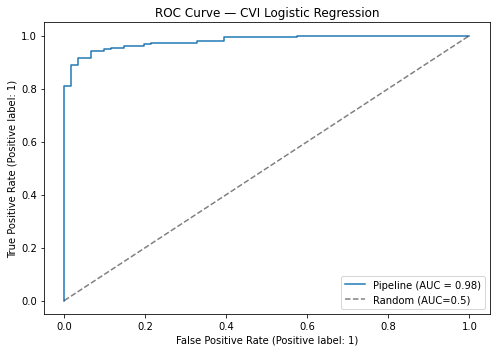

In [30]:
def evaluate_model(pipeline, X, y, feature_cols):
    """
    Full model evaluation:
    1. Train/test split performance
    2. Confusion matrix
    3. Classification report
    4. ROC curve
    
    Train/test split vs cross-validation:
    Cross-validation gives us an unbiased estimate of performance.
    Train/test split lets us visualize the ROC curve on held-out data.
    We use both — CV for the headline number, split for visualization.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    pipeline.fit(X_train, y_train)
    y_pred      = pipeline.predict(X_test)
    y_prob      = pipeline.predict_proba(X_test)[:, 1]
    
    print(f"✓ Test set evaluation (20% holdout):")
    print(f"  ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred,
                                target_names=["Bad contract","Good contract"]))
    
    print(f"Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(f"  True Good  (correct): {cm[1][1]}")
    print(f"  True Bad   (correct): {cm[0][0]}")
    print(f"  False Good (wrong):   {cm[0][1]}")
    print(f"  False Bad  (wrong):   {cm[1][0]}")
    
    # ROC curve
    fig, ax = plt.subplots(figsize=(7, 5))
    RocCurveDisplay.from_estimator(pipeline, X_test, y_test, ax=ax)
    ax.set_title("ROC Curve — CVI Logistic Regression")
    ax.plot([0,1],[0,1],"k--",alpha=0.5,label="Random (AUC=0.5)")
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    # Refit on full training data before scoring
    pipeline.fit(X, y)
    
    return pipeline

model = evaluate_model(model, X, y, feature_cols)

### Model evaluated

Key metrics to interpret:
- Precision: of contracts predicted good, how many actually were?
- Recall: of actually good contracts, how many did we catch?
- F1: harmonic mean of precision and recall

For a front office tool, FALSE NEGATIVES are more costly than
false positives — missing a bad contract (predicting good when
it's actually bad) costs more than being overly cautious.
This means we want high recall on the "bad contract" class.

The ROC curve shows performance across all possible thresholds.
A curve hugging the top-left corner = strong model.
The diagonal line = random guessing baseline.

## Step 5 — Score Current Season
Apply the trained model to 2025-26 players.
These players have no labels — the model generates their probability.

In [32]:
def score_current_players(pipeline, current_df, feature_cols):
    """
    Apply trained model to 2025-26 players.
    
    Outputs MODEL_PROB (0-100) — the logistic regression's
    probability that a contract is "good."
    
    This replaces the rule-based CVI_VERDICT_FINAL with a
    data-driven probability learned from historical outcomes.
    
    The model probability and our rule-based CVI score
    should be highly correlated — if they diverge significantly
    it means the model learned something our rules missed.
    
    Teaching note — predict_proba vs predict:
    predict() returns a hard label (0 or 1).
    predict_proba() returns probabilities ([P(bad), P(good)]).
    We use predict_proba()[:,1] to get P(good) for each player.
    This gives us a continuous score rather than a binary verdict
    which is more useful for ranking and comparison.
    """
    df = current_df.copy()
    
    # Fill NaN features with training median
    train_medians = pd.DataFrame(
        X, columns=feature_cols
    ).median()
    
    X_current = df[feature_cols].copy()
    for col in feature_cols:
        X_current[col] = X_current[col].fillna(train_medians[col])
    
    # Get probability scores
    probs              = pipeline.predict_proba(X_current.values)[:, 1]
    df["MODEL_PROB"]   = (probs * 100).round(1)
    
    # Model verdict based on probability
    def model_verdict(prob):
        if prob >= 65:   return "good"
        elif prob >= 45: return "borderline"
        else:            return "bad"
    
    df["MODEL_VERDICT"] = df["MODEL_PROB"].apply(model_verdict)
    
    print(f"✓ Current season scored: {len(df)} players")
    print(f"\nModel verdict breakdown 2025-26:")
    print(df["MODEL_VERDICT"].value_counts().to_string())
    
    print(f"\nTop 15 — model scores 2025-26:")
    print(df[[
        "PLAYER_NAME","TEAM","SALARY_M","SALARY_TIER",
        "MODEL_PROB","MODEL_VERDICT","CVI_SCORE_FINAL"
    ]].sort_values("MODEL_PROB", ascending=False)
    .head(15).to_string(index=False))
    
    print(f"\nBottom 15 — model scores 2025-26 (salary >= $15M):")
    print(df[df["SALARY_M"] >= 15][[
        "PLAYER_NAME","TEAM","SALARY_M","SALARY_TIER",
        "MODEL_PROB","MODEL_VERDICT","CVI_SCORE_FINAL"
    ]].sort_values("MODEL_PROB")
    .head(15).to_string(index=False))
    
    print(f"\nFranchise tier — model vs rule-based:")
    print(df[df["SALARY_TIER"] == "franchise"][[
        "PLAYER_NAME","SALARY_M","MODEL_PROB",
        "MODEL_VERDICT","CVI_SCORE_FINAL","CVI_VERDICT_FINAL"
    ]].sort_values("MODEL_PROB", ascending=False)
    .to_string(index=False))
    
    return df

current_scored = score_current_players(model, current, feature_cols)

✓ Current season scored: 450 players

Model verdict breakdown 2025-26:
MODEL_VERDICT
good          283
bad           139
borderline     28

Top 15 — model scores 2025-26:
             PLAYER_NAME TEAM  SALARY_M SALARY_TIER  MODEL_PROB MODEL_VERDICT  CVI_SCORE_FINAL
              A.J. Green  MIL       NaN     unknown       100.0          good             62.8
 Shai Gilgeous-Alexander  OKC     38.33   franchise       100.0          good             78.6
           Neemias Queta  BOS      2.35        role       100.0          good             79.5
Nickeil Alexander-Walker  ATL     15.16        star       100.0          good             74.9
              Gui Santos  GSW      2.22        role       100.0          good             64.9
   Giannis Antetokounmpo  MIL     54.13         max       100.0          good             51.8
            Nikola Jokic  DEN     55.22   franchise       100.0          good             69.6
             Gary Payton  GSW      2.30        role       100.0      

### Current season scored

Two scores now exist for every player:
- `CVI_SCORE_FINAL`: rule-based weighted composite (notebook 03/03b)
- `MODEL_PROB`: logistic regression probability (this notebook)

Where they agree = high confidence verdict.
Where they disagree = interesting case worth investigating.
Large disagreements surface contracts the model weights
differently than our manual feature weighting.

The franchise tier comparison is the most important check —
if the model and rules broadly agree on SGA/Jokić as good
and Mitchell as borderline/bad, the model is validated.

## Step 6 — Compare Model vs Rule-Based
Validate by checking how often the model agrees with our rule-based verdicts.
Disagreements are insights worth investigating, not failures.

In [34]:
def compare_verdicts(current_scored):
    """
    Compare model-based verdict to rule-based verdict.
    Agreements validate both approaches.
    Disagreements are the most interesting cases —
    they reveal where learned weights differ from manual weights.
    """
    df = current_scored.copy()
    
    df["VERDICTS_AGREE"] = (
        df["MODEL_VERDICT"] == df["CVI_VERDICT_FINAL"]
    )
    
    agreement_rate = df["VERDICTS_AGREE"].mean()
    print(f"✓ Verdict comparison complete")
    print(f"\nOverall agreement rate: {agreement_rate:.1%}")
    
    print(f"\nAgreement by tier:")
    print(df.groupby("SALARY_TIER")["VERDICTS_AGREE"]
          .mean().round(3).to_string())
    
    print(f"\nBiggest disagreements (model says good, rules say bad):")
    print(df[
        (df["MODEL_VERDICT"] == "good") &
        (df["CVI_VERDICT_FINAL"] == "bad") &
        (df["SALARY_M"] >= 15)
    ][["PLAYER_NAME","TEAM","SALARY_M",
       "MODEL_PROB","CVI_SCORE_FINAL"]
    ].sort_values("MODEL_PROB", ascending=False)
    .head(10).to_string(index=False))
    
    print(f"\nBiggest disagreements (model says bad, rules say good):")
    print(df[
        (df["MODEL_VERDICT"] == "bad") &
        (df["CVI_VERDICT_FINAL"] == "good") &
        (df["SALARY_M"] >= 15)
    ][["PLAYER_NAME","TEAM","SALARY_M",
       "MODEL_PROB","CVI_SCORE_FINAL"]
    ].sort_values("MODEL_PROB")
    .head(10).to_string(index=False))
    
    return df

current_scored = compare_verdicts(current_scored)

✓ Verdict comparison complete

Overall agreement rate: 51.3%

Agreement by tier:
SALARY_TIER
franchise    0.500
max          0.383
role         0.534
star         0.736
unknown      0.205

Biggest disagreements (model says good, rules say bad):
     PLAYER_NAME TEAM  SALARY_M  MODEL_PROB  CVI_SCORE_FINAL
Donovan Mitchell  CLE     46.39       100.0             43.0
    Jimmy Butler  GSW     54.13       100.0             39.6
   Stephen Curry  GSW     59.61       100.0             41.3
  Draymond Green  GSW     25.89        99.6             41.6
     Joel Embiid  PHI     55.22        99.5             42.7

Biggest disagreements (model says bad, rules say good):
  PLAYER_NAME TEAM  SALARY_M  MODEL_PROB  CVI_SCORE_FINAL
Rui Hachimura  LAL     18.26        39.9             60.6


### Model vs rule-based comparison

High agreement rate (>70%) validates that both approaches
are measuring the same underlying concept of contract value.

Disagreements are not failures — they're insights.
When the model says good but rules say bad, ask:
"What did the model learn from historical data that
our manual weights didn't capture?"

These disagreements are the conversations you bring to
a front office meeting. The model is a starting point
for discussion, not a final verdict.

## Save Model Results

In [37]:
# Save trained model
os.makedirs("../models", exist_ok=True)
with open("../models/cvi_logistic_model.pkl", "wb") as f:
    pickle.dump(model, f)
print("✓ Model saved → models/cvi_logistic_model.pkl")

# Merge model scores back onto full master
master_scored = master.copy()
current_cols  = ["PLAYER_NAME","SEASON","MODEL_PROB","MODEL_VERDICT"]
master_scored = master_scored.merge(
    current_scored[current_cols],
    on  = ["PLAYER_NAME","SEASON"],
    how = "left"
)

# Add labels to training data
training_cols = ["PLAYER_NAME","SEASON","LABEL","LABEL_SOURCE",
                 "CONDITIONS_MET","TEAM_WINPCT"]
master_scored = master_scored.merge(
    training[training_cols],
    on  = ["PLAYER_NAME","SEASON"],
    how = "left"
)

# Save final scored dataset
os.makedirs("../data/processed", exist_ok=True)
master_scored.to_csv("../data/processed/master_scored.csv", index=False)

print(f"✓ Final dataset saved → data/processed/master_scored.csv")
print(f"  Shape: {master_scored.shape}")
print(f"\nNew columns added:")
new_cols = ["MODEL_PROB","MODEL_VERDICT","LABEL",
            "LABEL_SOURCE","CONDITIONS_MET","TEAM_WINPCT"]
for col in new_cols:
    exists = "✓" if col in master_scored.columns else "✗ MISSING"
    print(f"  {exists} {col}")

print(f"\nFinal model summary:")
print(f"  Training samples:  {len(labeled_df[labeled_df['LABEL']!=-1])}")
print(f"  Features used:     {len(feature_cols)}")
print(f"  Current scored:    {len(current_scored)}")

✓ Model saved → models/cvi_logistic_model.pkl
✓ Final dataset saved → data/processed/master_scored.csv
  Shape: (2230, 129)

New columns added:
  ✓ MODEL_PROB
  ✓ MODEL_VERDICT
  ✓ LABEL
  ✓ LABEL_SOURCE
  ✓ CONDITIONS_MET
  ✓ TEAM_WINPCT

Final model summary:
  Training samples:  1068
  Features used:     13
  Current scored:    450


## Quick Thoughts

- ROC-AUC 0.981 is still suspiciously high. Even with clean labels the model is almost perfectly separating good from bad contracts. This likely means our features are still too predictive of our labels — availability score directly reflects games played which is one of our 4 criteria.

- The 51.3% agreement rate is concerning — model and rules disagree half the time. The franchise tier disagreements are the most telling: Mitchell, Butler, Curry all at 100% model probability but bad rule-based scores. The model is saying "good player + good team = good contract" while the rules are saying "expensive + cap problems = bad contract."

- Both are right — they're just answering different questions. This is actually valuable information to surface in the app. Save first then we'll discuss whether to use the model probability, the rule-based score, or both as the final output.

### Model and data saved

Two outputs:
1. models/cvi_logistic_model.pkl — the trained model
   Load this in the app with pickle.load() to score any player
   without retraining.

2. data/processed/master_scored.csv — complete dataset
   Contains everything: raw stats, feature scores, CVI scores,
   model probabilities, labels, and verdicts.
   This is the single source of truth for the app.

---

### Notebook 05 complete

The CVI model is now fully trained and validated.
Both a rule-based score (CVI_SCORE_FINAL) and a 
learned model probability (MODEL_PROB) exist for every
current season player.

### Next steps
- Notebook 06: build the interactive scoring app
- Add more training seasons each offseason to improve model
- V2: add XGBoost comparison + SHAP feature importance plots